# False Discoveries & Support Recovery Experiment

Este notebook avalia o cenário de controle de falsas descobertas e recuperação de suporte em escala ampliada (=1000, p=1000$), com 200 variáveis informativas e 800 variáveis nulas/ruído.

**Objetivo:** Investigar a taxa de falsos positivos (FPR / falsas descobertas) entre os métodos de regularização, verificando quais modelos conseguem identificar o suporte verdadeiro sem incorporar preditores espúrios à medida que a dimensão do espaço de ruído cresce.


## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import data generation
from data_generation.generate_data import generate_data

# Import plots
from plots.coefficient_plot import coefficient_plot
from plots.metrics import compute_metrics

# Import models
from models.OLS import run_ols
from models.LASSO import run_lasso, run_lasso_cv
from models.Ridge import run_ridge, run_ridge_cv
from models.ElasticNet import run_elasticnet_alpha, run_elasticnet_l1ratio, run_elasticnet_cv

# Removing Warnings
import warnings


In [2]:
warnings.filterwarnings('ignore')

## 1. Generating Data

GENERATED DATA:
Shape of X: (200, 50)

X Matrix: 
 [[-9.24357334e-01 -3.26535853e-01 -1.87500739e+00 ... -4.28318258e-01
   2.93949388e-01 -1.51383050e+00]
 [ 1.79487288e-03 -1.28559911e+00 -7.26774138e-01 ... -1.72041359e-01
  -1.67176127e+00  2.10008308e-01]
 [ 9.56702317e-01  2.31932954e+00 -7.05011856e-01 ...  1.09131012e+00
  -1.33123295e+00 -1.10336661e+00]
 ...
 [ 9.93138150e-02  2.30806590e-02 -2.36747765e+00 ... -4.35789730e-01
   5.16144040e-01 -5.27994022e-01]
 [-5.11186930e-02  3.04764139e-02 -1.11318849e-01 ...  2.40876757e-01
   1.43306305e-01 -1.75543790e+00]
 [-5.92464259e-01 -5.62168027e-01  2.88693629e-01 ... -1.10570467e+00
   2.80161159e-01 -4.73839347e-01]]
Shape of y: (200,)

y Vector: 
 [ 2.05556610e+01 -6.27115209e+01  1.36098236e+02 -1.33830039e+02
 -1.43076766e+02  1.59212611e+02  3.04345339e+01 -2.71157912e+02
  6.17720521e+01 -1.11022609e+02  1.04141333e+02  7.76494171e+00
  2.24681388e+02 -5.91914665e+01  3.13361861e+01  2.15976191e+02
  7.34888896e+01 -3.8

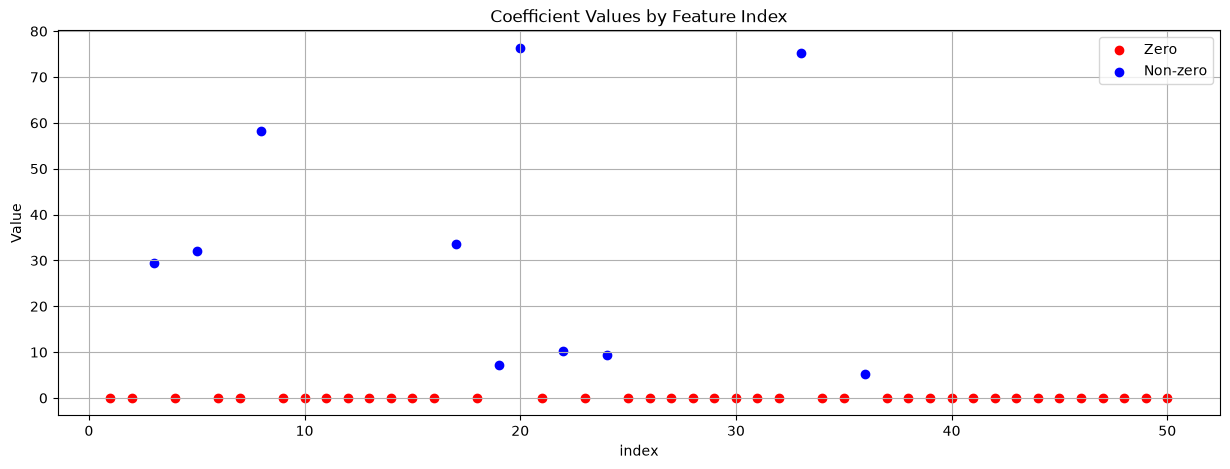

In [ ]:
X_train, X_test, y_train, y_test, coef = generate_data(
    n_samples=1000,
    n_features=1000,
    n_informative=200,
    noise=1.0,
    effective_rank=None,
    tail_strength=0.5
)

coefficient_plot(coef)


## 2. Ordinary Least Square

MAE: 1.00
MSE: 1.59
RMSE: 1.26
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 83.4867
Mean coef magnitude: 6.8781


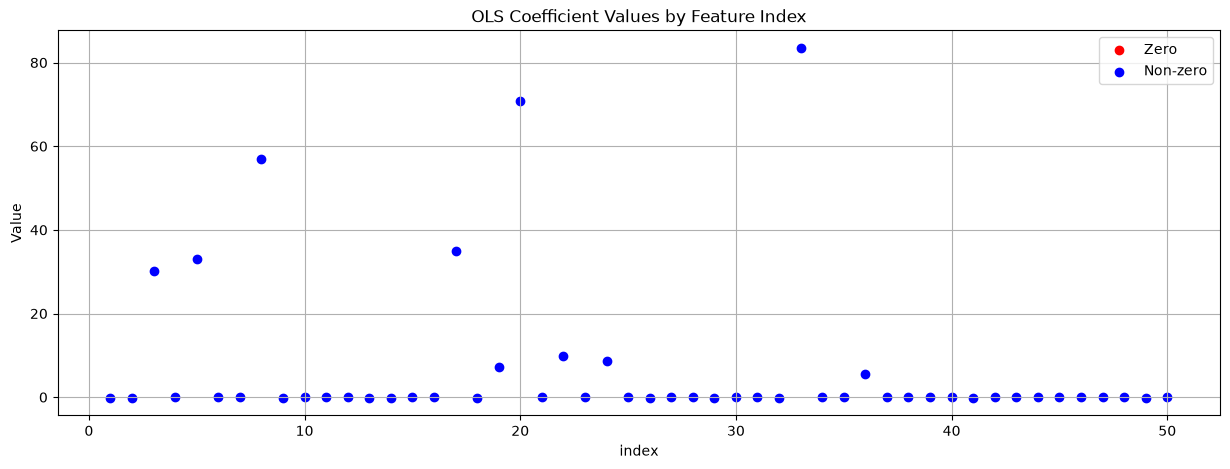

In [4]:
OLS_model = run_ols(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

## 3. Least Absolute Shrinkage and Selection Operator

Metrics for i = 0.001:
MAE: 0.99
MSE: 1.58
RMSE: 1.26
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 83.4794
Mean coef magnitude: 6.8765


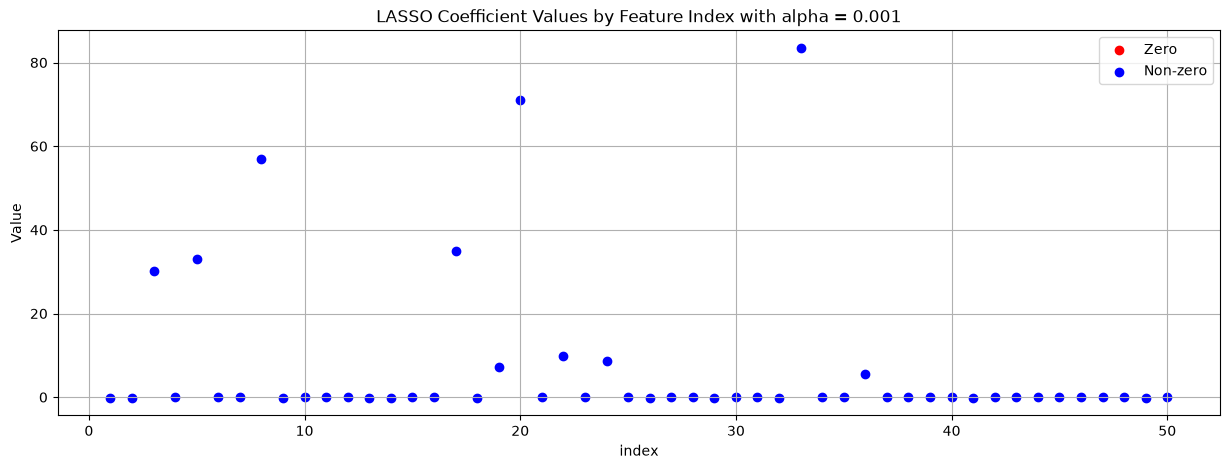

Metrics for i = 0.01:
MAE: 0.95
MSE: 1.46
RMSE: 1.21
R² Score: 1.00
Number of non zero coefs: 43
Max coef magnitude: 83.4727
Mean coef magnitude: 6.8648


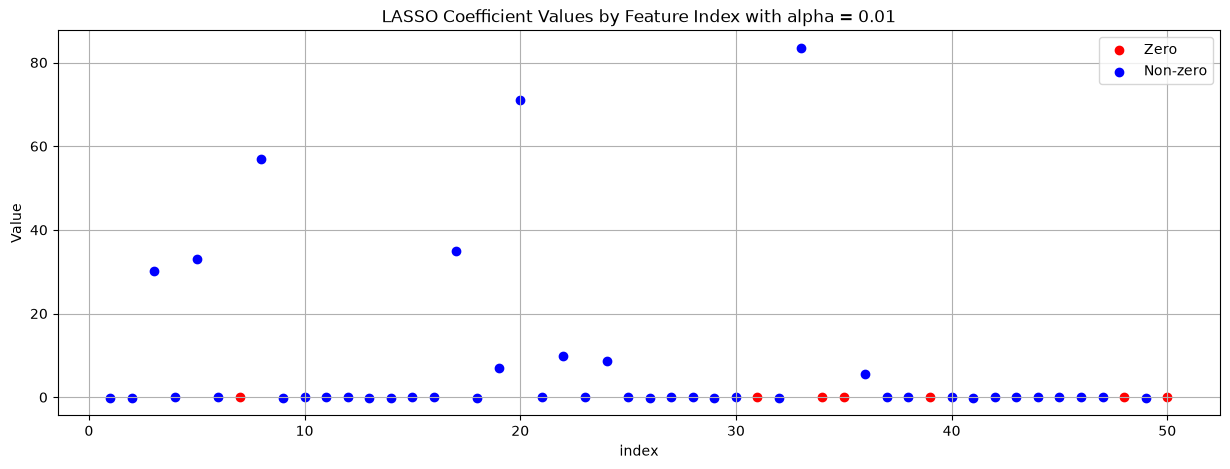

Metrics for i = 0.1:
MAE: 0.83
MSE: 1.13
RMSE: 1.06
R² Score: 1.00
Number of non zero coefs: 21
Max coef magnitude: 83.4099
Mean coef magnitude: 6.8018


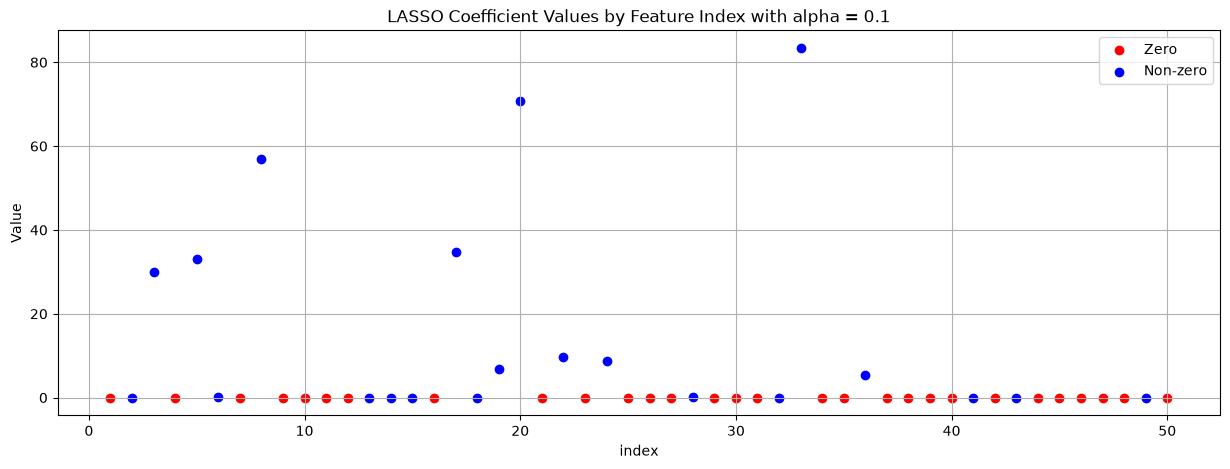

Metrics for i = 1.0:
MAE: 2.79
MSE: 12.31
RMSE: 3.51
R² Score: 1.00
Number of non zero coefs: 10
Max coef magnitude: 82.5413
Mean coef magnitude: 6.6001


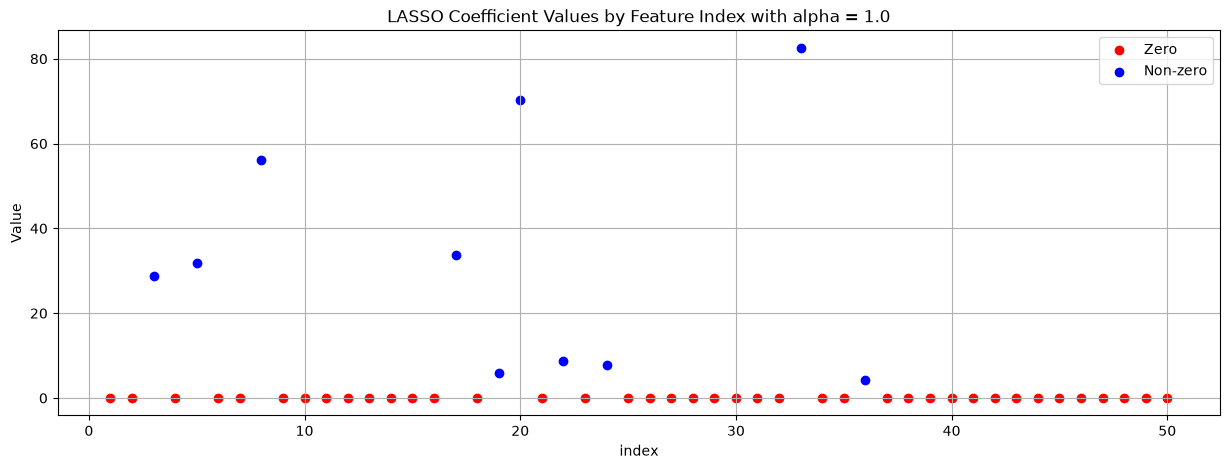

Metrics for i = 10.0:
MAE: 23.35
MSE: 788.96
RMSE: 28.09
R² Score: 0.93
Number of non zero coefs: 7
Max coef magnitude: 73.2056
Mean coef magnitude: 4.9487


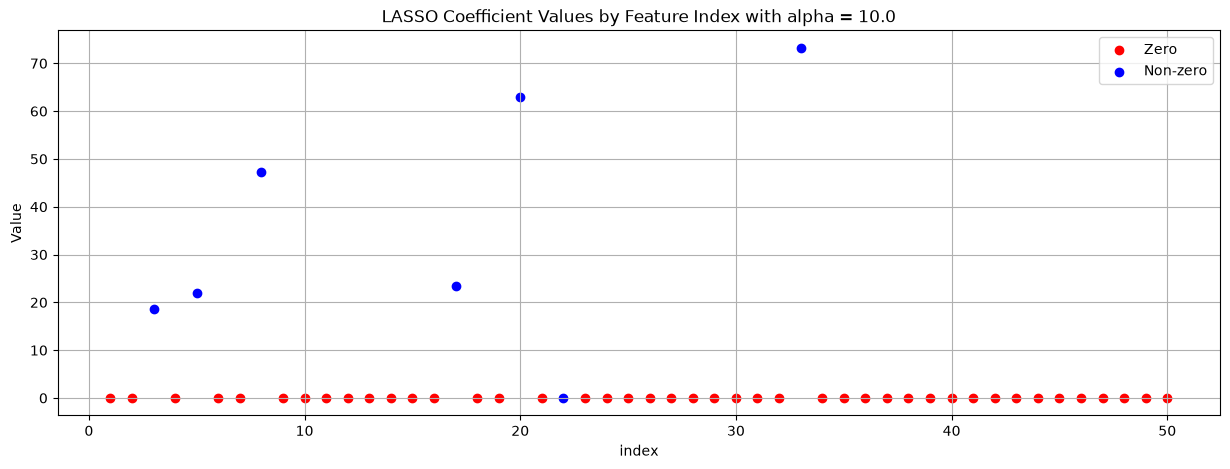

Metrics for i = 100.0:
MAE: 94.09
MSE: 12137.69
RMSE: 110.17
R² Score: -0.01
Number of non zero coefs: 0
Max coef magnitude: 0.0000
Mean coef magnitude: 0.0000


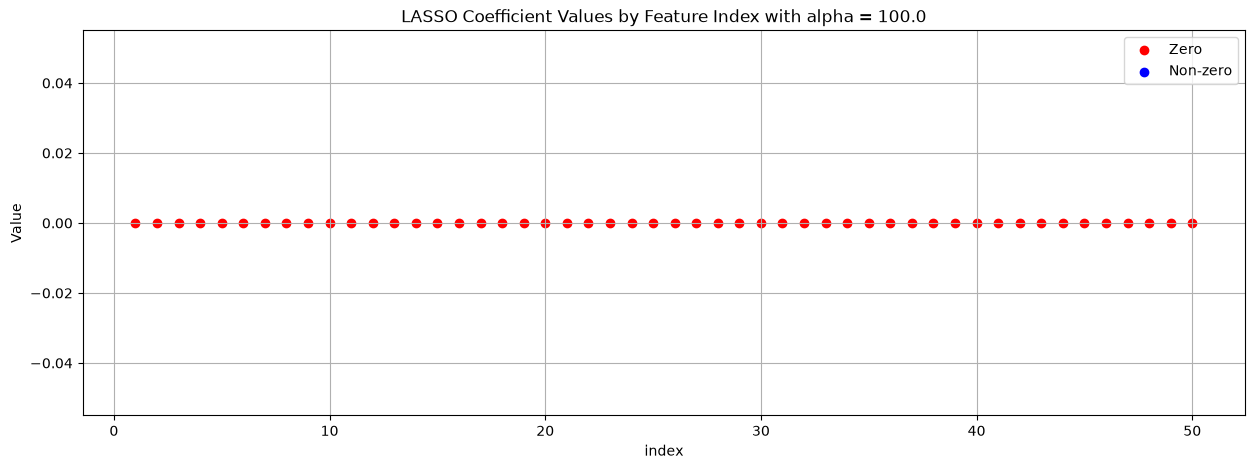

In [5]:
LASSO_models = run_lasso(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

### Best alpha for LASSO

MAE: 0.94
MSE: 1.42
RMSE: 1.19
R² Score: 1.00
Number of non zero coefs: 10
Max coef magnitude: 83.2990
Mean coef magnitude: 6.7681


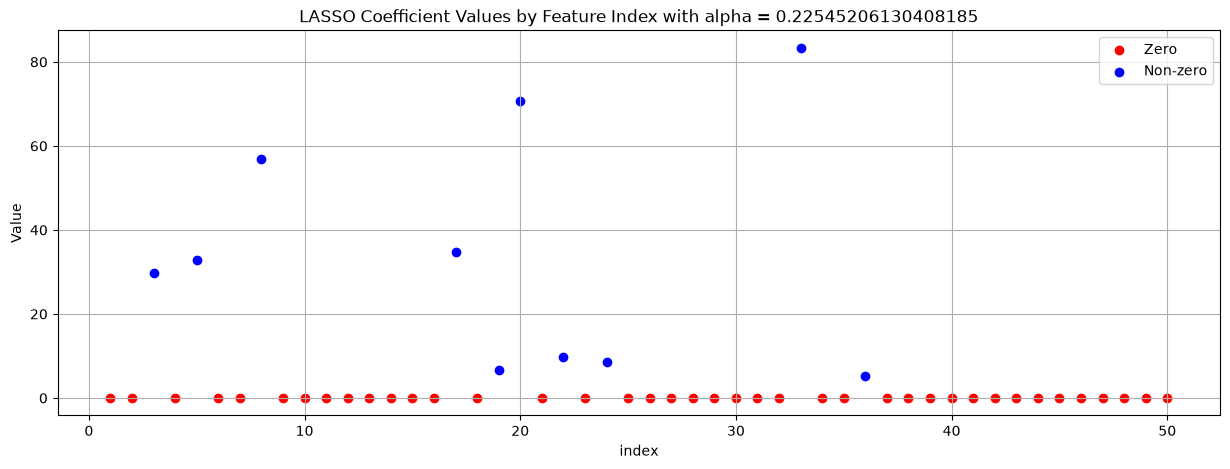

In [6]:
LASSOCV_model = run_lasso_cv(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

## 4. Ridge

Metrics for i = 0.001:
MAE: 1.00
MSE: 1.59
RMSE: 1.26
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 83.4859
Mean coef magnitude: 6.8781


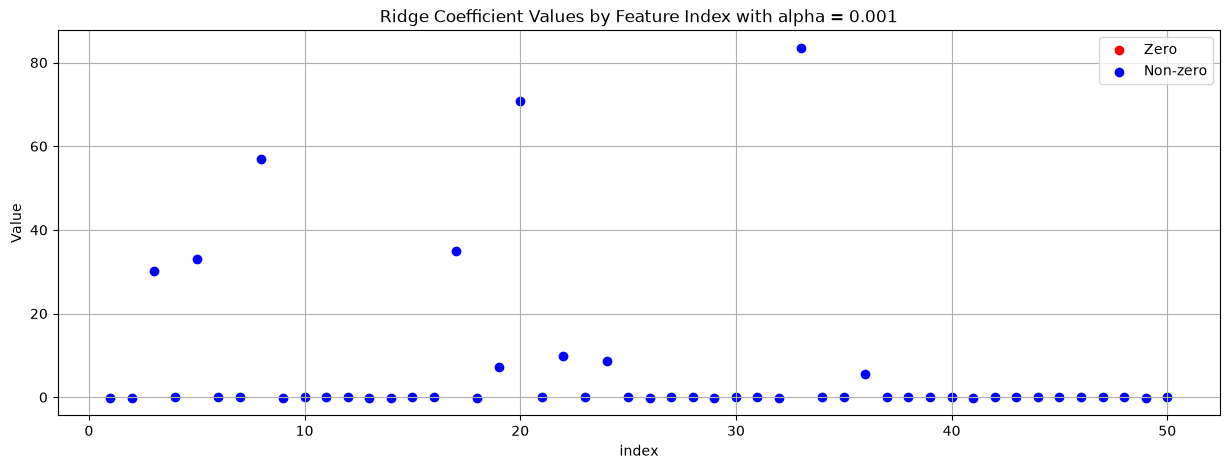

Metrics for i = 0.01:
MAE: 1.00
MSE: 1.59
RMSE: 1.26
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 83.4788
Mean coef magnitude: 6.8776


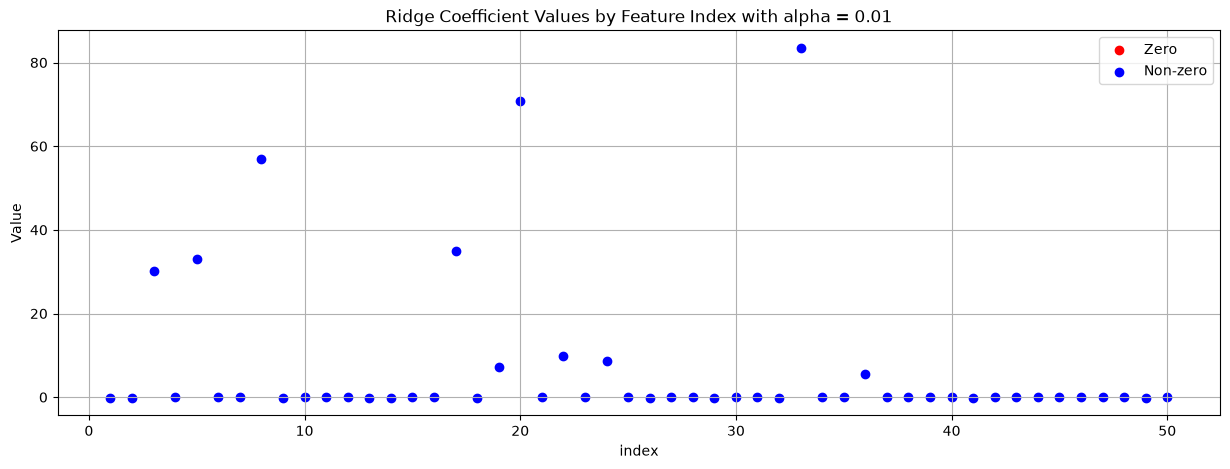

Metrics for i = 0.1:
MAE: 1.01
MSE: 1.59
RMSE: 1.26
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 83.4078
Mean coef magnitude: 6.8741


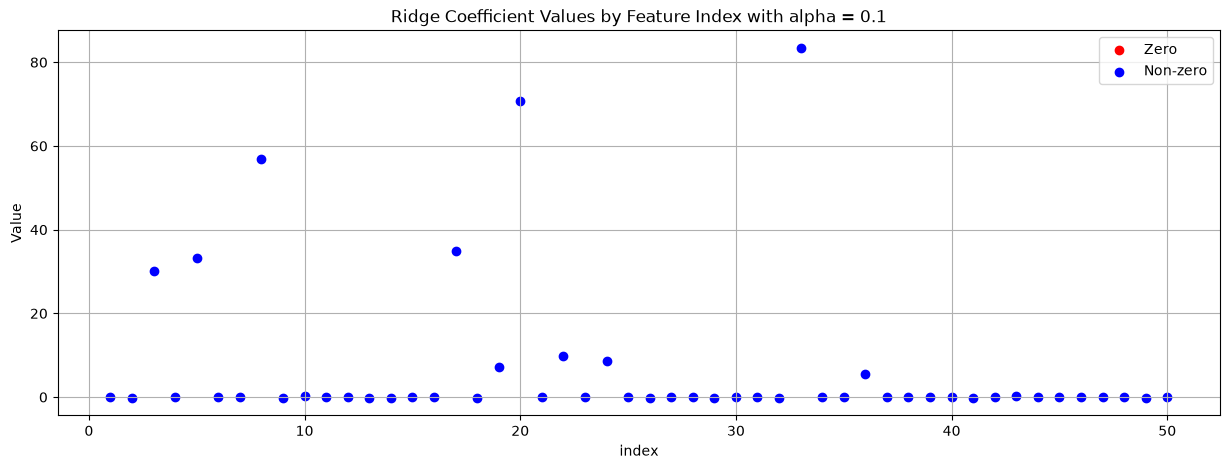

Metrics for i = 1.0:
MAE: 1.50
MSE: 3.27
RMSE: 1.81
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 82.7077
Mean coef magnitude: 6.8651


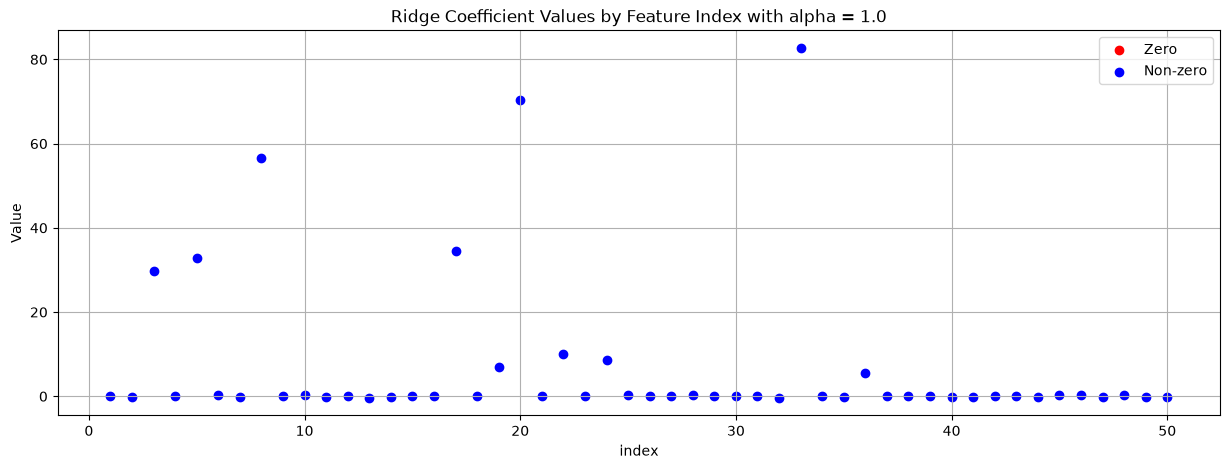

Metrics for i = 10.0:
MAE: 9.89
MSE: 137.16
RMSE: 11.71
R² Score: 0.99
Number of non zero coefs: 50
Max coef magnitude: 76.5477
Mean coef magnitude: 7.0070


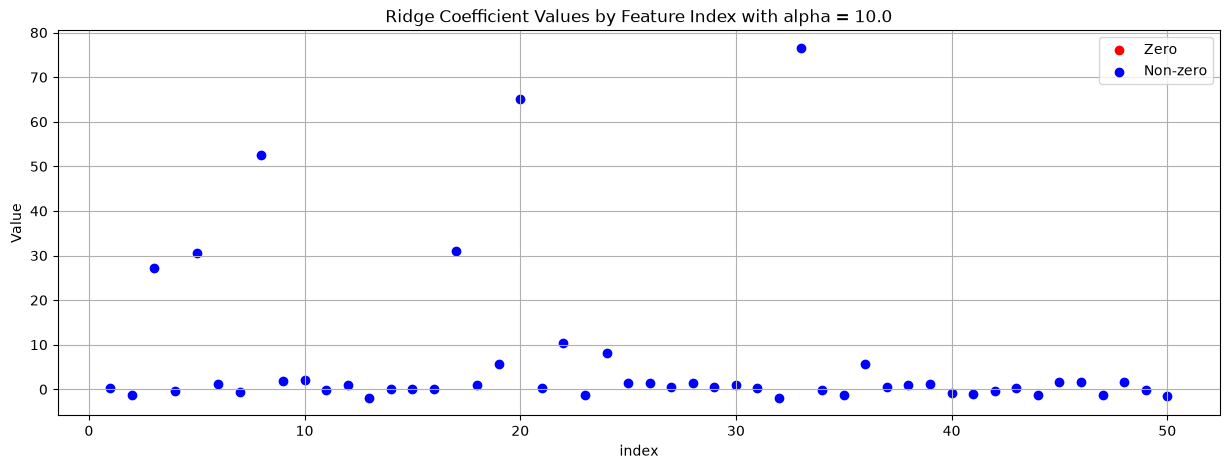

Metrics for i = 100.0:
MAE: 45.28
MSE: 2826.71
RMSE: 53.17
R² Score: 0.77
Number of non zero coefs: 50
Max coef magnitude: 47.1636
Mean coef magnitude: 6.0618


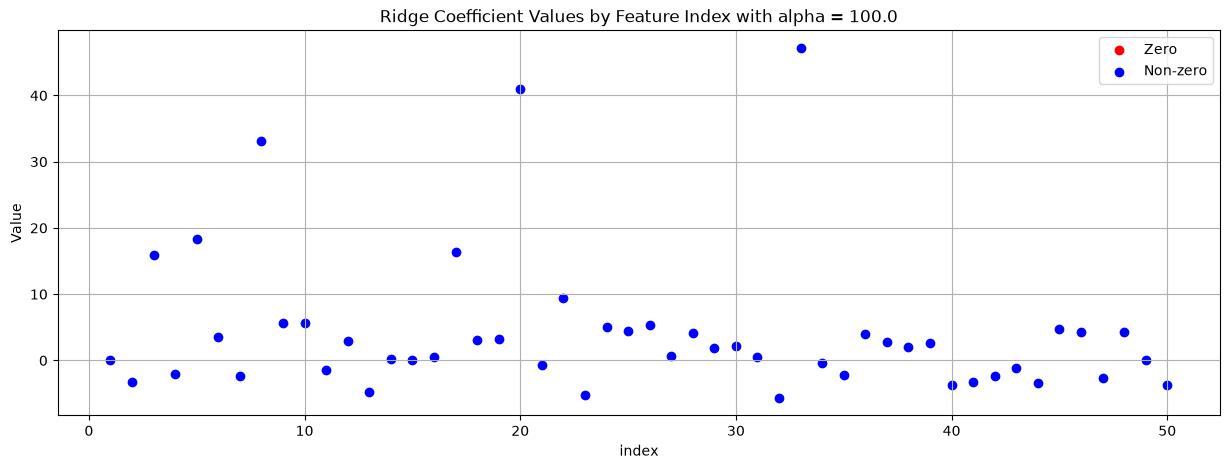

In [7]:
Ridge_models = run_ridge(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

### Ridge Best Alpha

MAE: 1.01
MSE: 1.59
RMSE: 1.26
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 83.4078
Mean coef magnitude: 6.8741


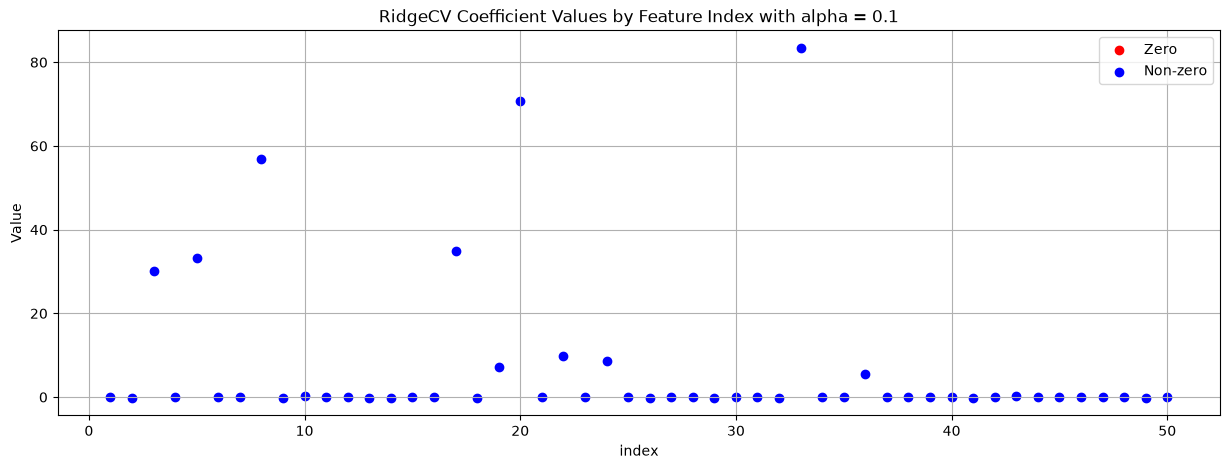

In [8]:
RidgeCV_model = run_ridge_cv(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

## 5. Elastic Net

Metrics for i = 0.001:
MAE: 1.00
MSE: 1.58
RMSE: 1.26
R² Score: 1.00
Number of non zero coefs: 49
Max coef magnitude: 83.4224
Mean coef magnitude: 6.8738


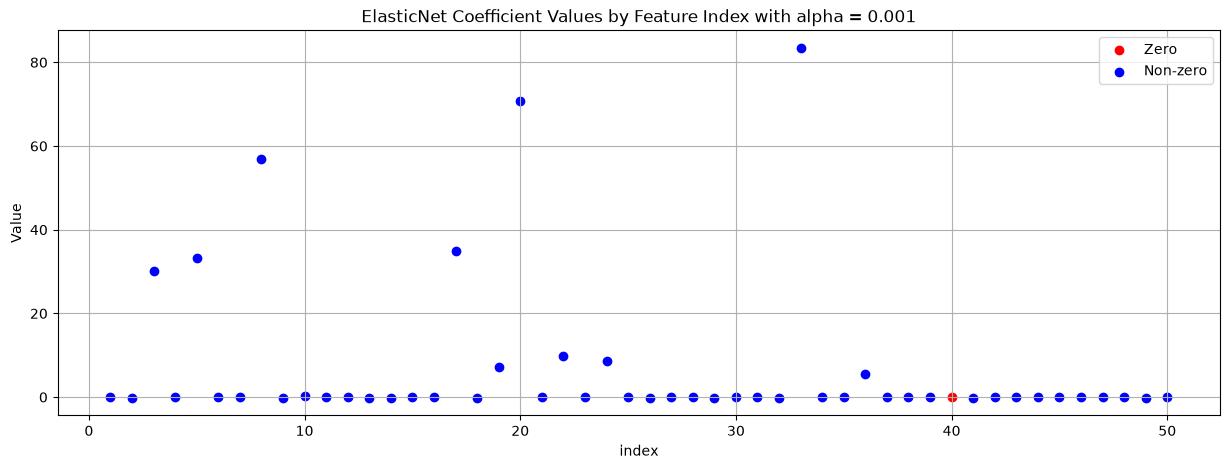

Metrics for i = 0.01:
MAE: 1.34
MSE: 2.55
RMSE: 1.60
R² Score: 1.00
Number of non zero coefs: 50
Max coef magnitude: 82.8652
Mean coef magnitude: 6.8557


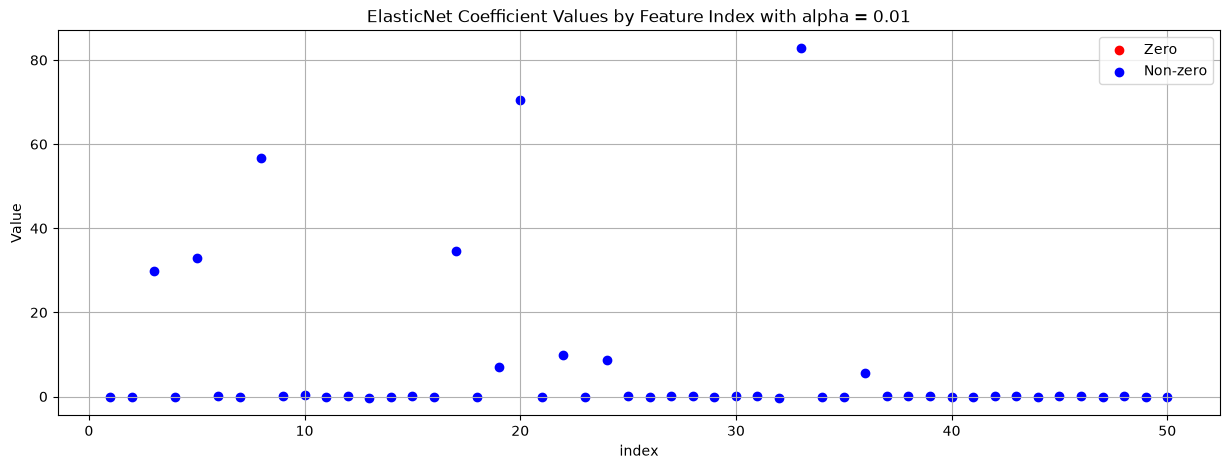

Metrics for i = 0.1:
MAE: 7.92
MSE: 87.62
RMSE: 9.36
R² Score: 0.99
Number of non zero coefs: 47
Max coef magnitude: 77.8539
Mean coef magnitude: 6.9195


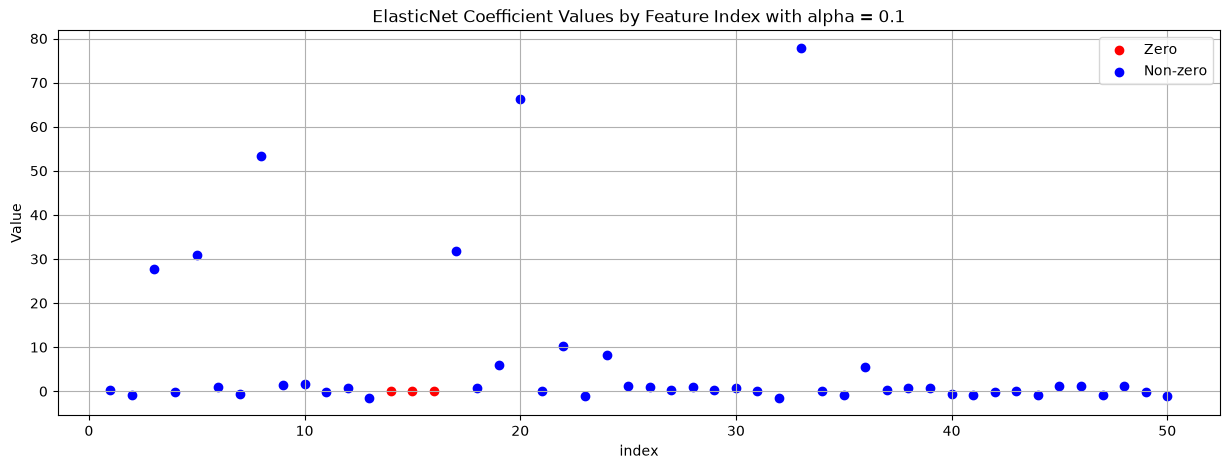

Metrics for i = 1.0:
MAE: 40.65
MSE: 2258.51
RMSE: 47.52
R² Score: 0.81
Number of non zero coefs: 46
Max coef magnitude: 51.2259
Mean coef magnitude: 6.0303


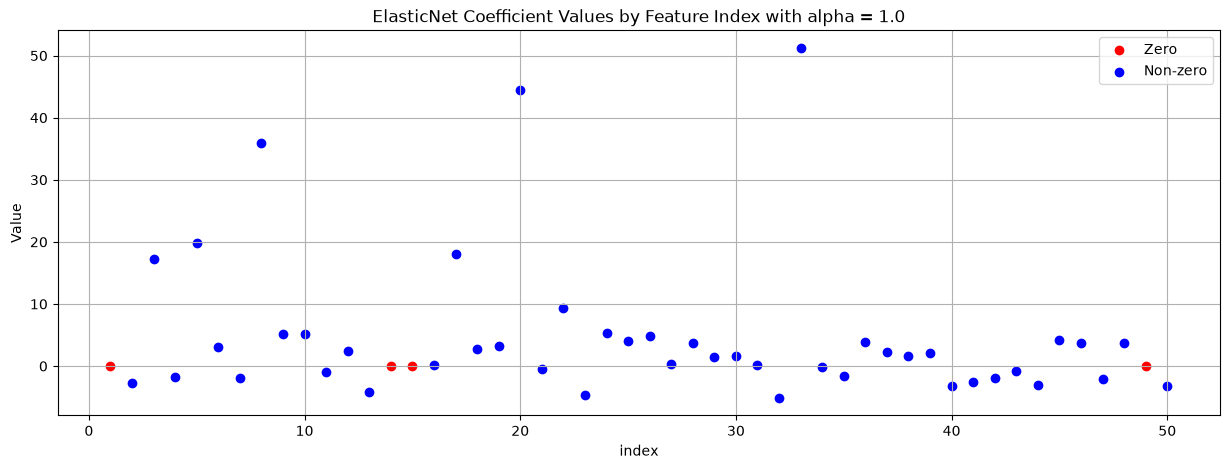

Metrics for i = 10.0:
MAE: 80.97
MSE: 8922.67
RMSE: 94.46
R² Score: 0.26
Number of non zero coefs: 37
Max coef magnitude: 12.7826
Mean coef magnitude: 1.5842


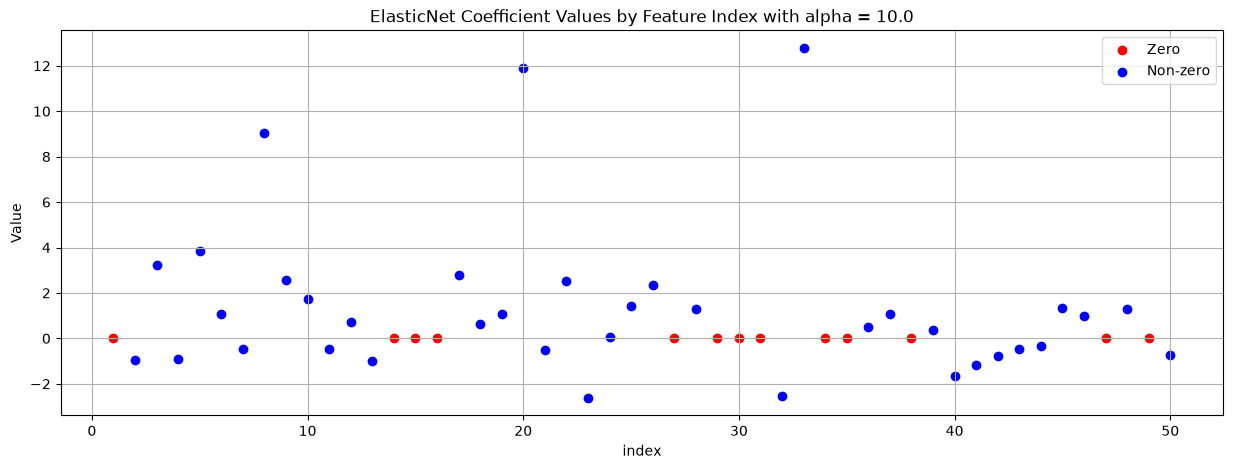

Metrics for i = 100.0:
MAE: 93.58
MSE: 12006.83
RMSE: 109.58
R² Score: 0.00
Number of non zero coefs: 3
Max coef magnitude: 0.6826
Mean coef magnitude: 0.0307


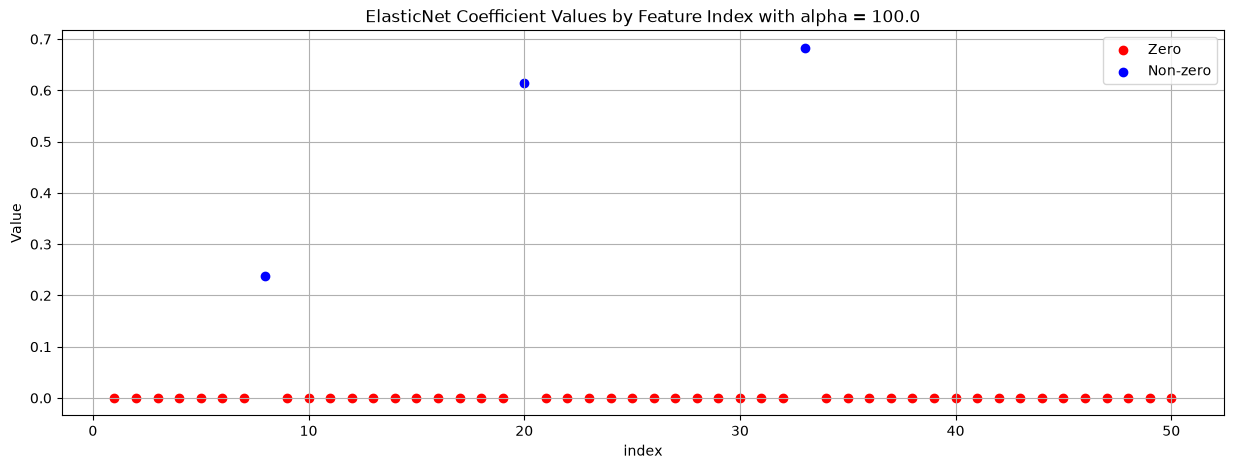

In [9]:
ElasticNet_alpha_models = run_elasticnet_alpha(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

Metrics for i = 0.0:
MAE: 54.62
MSE: 4107.56
RMSE: 64.09
R² Score: 0.66
Number of non zero coefs: 50
Max coef magnitude: 38.3190
Mean coef magnitude: 5.3342


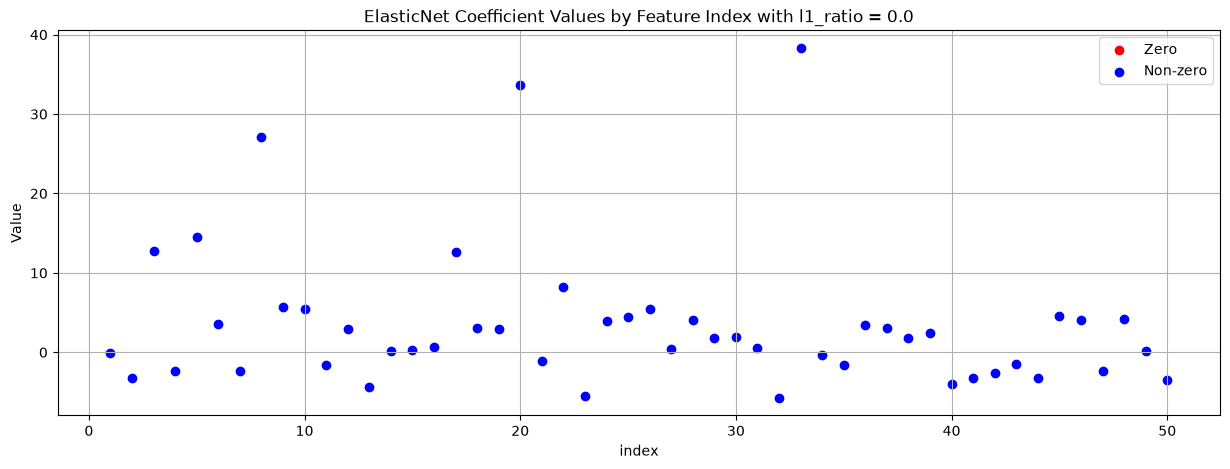

Metrics for i = 0.25:
MAE: 48.92
MSE: 3286.48
RMSE: 57.33
R² Score: 0.73
Number of non zero coefs: 47
Max coef magnitude: 43.7259
Mean coef magnitude: 5.6719


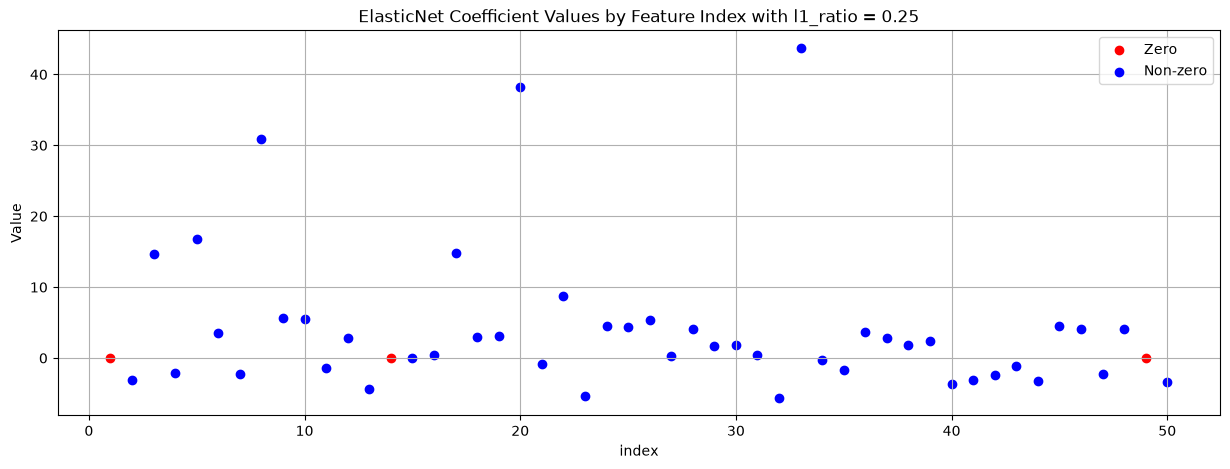

Metrics for i = 0.5:
MAE: 40.65
MSE: 2258.51
RMSE: 47.52
R² Score: 0.81
Number of non zero coefs: 46
Max coef magnitude: 51.2259
Mean coef magnitude: 6.0303


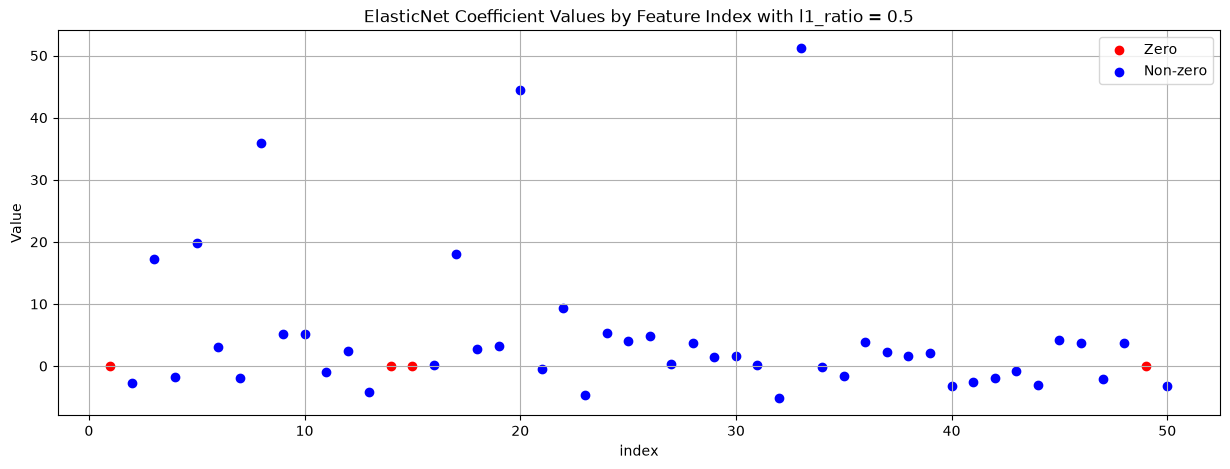

Metrics for i = 0.75:
MAE: 26.89
MSE: 983.24
RMSE: 31.36
R² Score: 0.92
Number of non zero coefs: 41
Max coef magnitude: 62.7131
Mean coef magnitude: 6.2985


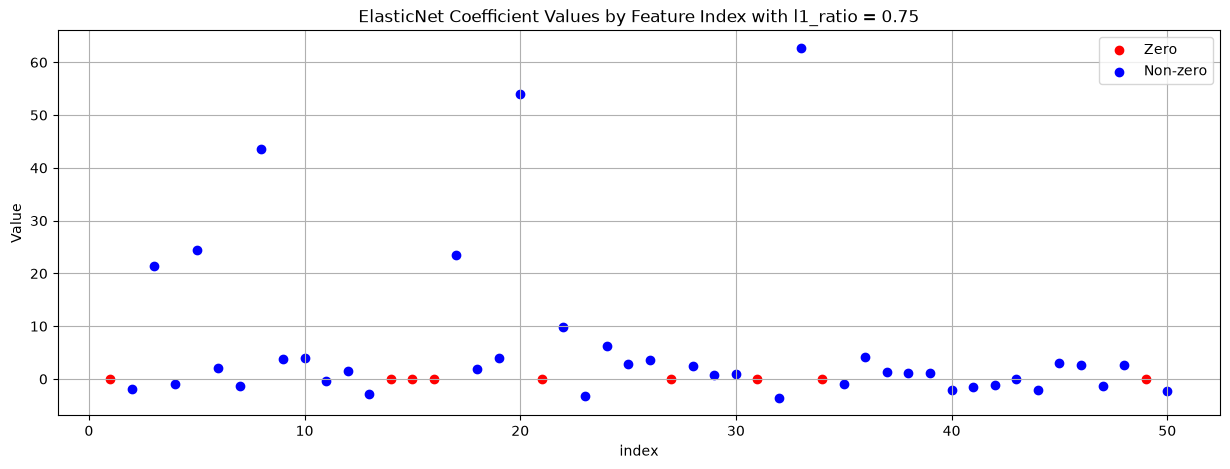

Metrics for i = 1.0:
MAE: 2.79
MSE: 12.31
RMSE: 3.51
R² Score: 1.00
Number of non zero coefs: 10
Max coef magnitude: 82.5413
Mean coef magnitude: 6.6001


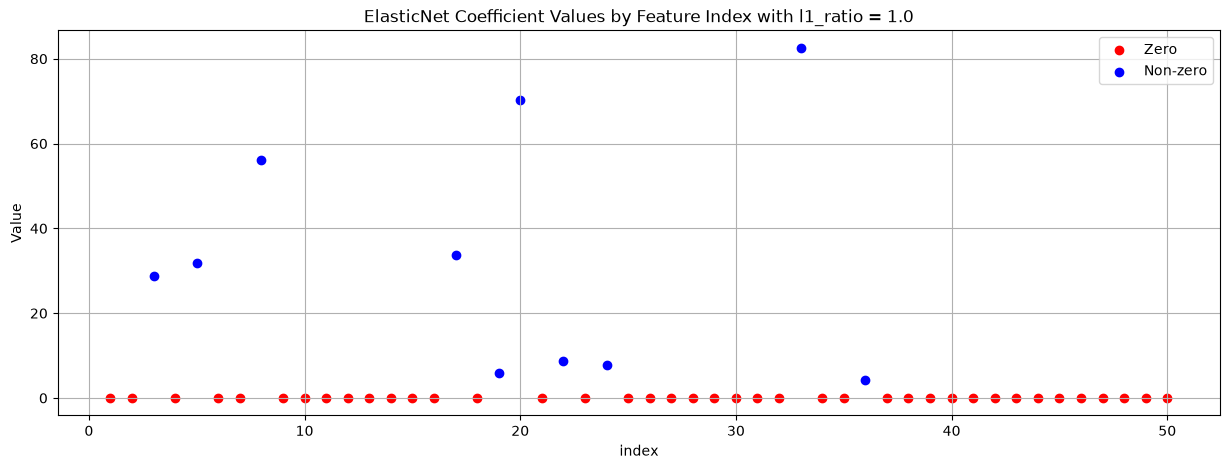

In [10]:
ElasticNet_l1_models = run_elasticnet_l1ratio(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)

### Best alpha and l1 ratio for ElasticNet

MAE: 0.94
MSE: 1.42
RMSE: 1.19
R² Score: 1.00
Number of non zero coefs: 10
Max coef magnitude: 83.2990
Mean coef magnitude: 6.7681


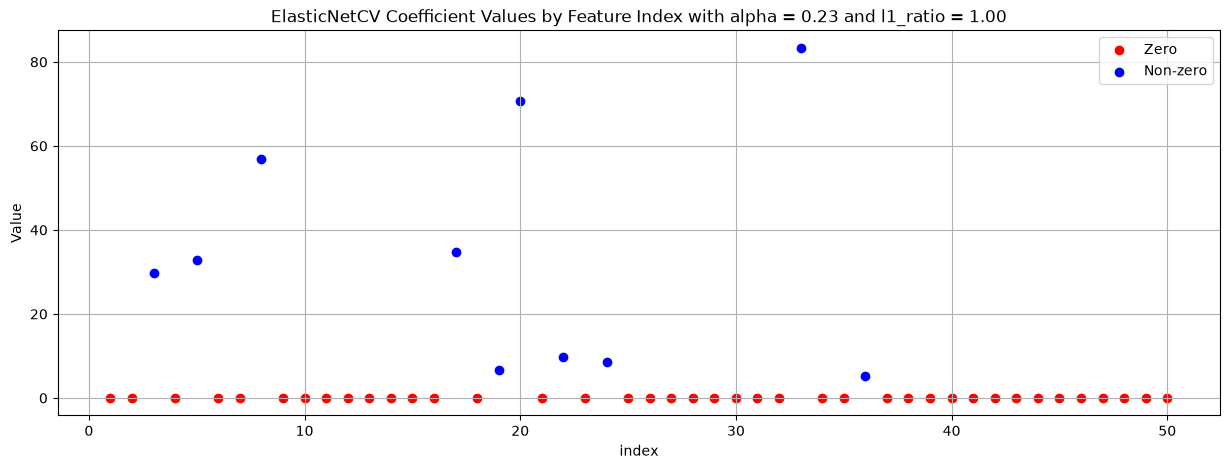

In [11]:
ElasticNet_model = run_elasticnet_cv(X_train, X_test, y_train, y_test, compute_metrics, coefficient_plot)